# Trader Performance & Market Sentiment
## Data Science Assignment Submission

**Dataset:** Hyperliquid Historical Trade Data + Bitcoin Fear & Greed Index  
**Period:** May 2023 – May 2025  
**Objective:** Explore the relationship between market sentiment and trader execution performance.

---

### Executive Summary

This analysis cross-references over 184,000 trade executions with daily Bitcoin sentiment classifications. The data empirically demonstrates that **Fear market conditions yield the highest gross profitability and peak win rates** — contradicting standard retail trading assumptions that calm or bullish markets are the most profitable.


## 1. Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

df_hist = pd.read_csv('historical_data.csv')
df_fgi  = pd.read_csv('fear_greed_index.csv')

print("Historical trades:", len(df_hist))
print("Fear & Greed records:", len(df_fgi))
print("\nHistorical columns:", df_hist.columns.tolist())
print("\nSample:")
df_hist[['Account','Coin','Side','Direction','Closed PnL','Timestamp IST']].head(3)

Historical trades: 211224
Fear & Greed records: 2644

Historical columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Sample:


,Account,Coin,Side,Direction,Closed PnL,Timestamp IST
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,0.0,02-12-2024 22:50
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,0.0,02-12-2024 22:50
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,0.0,02-12-2024 22:50


## 2. Date Formatting & Merge

In [2]:
# parse dates
df_hist['Date'] = pd.to_datetime(df_hist['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d')
df_fgi['Date']  = pd.to_datetime(df_fgi['date']).dt.strftime('%Y-%m-%d')

# merge on date
df_merged = pd.merge(df_hist, df_fgi[['Date','value','classification']], on='Date', how='inner')
df_merged['Closed PnL'] = pd.to_numeric(df_merged['Closed PnL'], errors='coerce').fillna(0)
df_merged['Size USD']   = pd.to_numeric(df_merged['Size USD'], errors='coerce').fillna(0)

print(f"Total historical trades : {len(df_hist):,}")
print(f"Successfully merged     : {len(df_merged):,}")
print(f"\nSentiment distribution:")
print(df_merged['classification'].value_counts())

Total historical trades : 211,224
Successfully merged     : 211,218

Sentiment distribution:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


## 3. Aggregated Performance Metrics

In [3]:
# closed trades only (realized PnL)
closed = df_merged[df_merged['Closed PnL'] != 0].copy()

sent_order = ['Fear', 'Greed', 'Extreme Greed', 'Neutral', 'Extreme Fear']

stats = closed.groupby('classification').agg(
    Total_Closed_Trades=('Account', 'count'),
    Total_Realized_PnL=('Closed PnL', 'sum'),
    Avg_PnL_per_Trade=('Closed PnL', 'mean')
).reset_index()

winners = (
    closed[closed['Closed PnL'] > 0]
    .groupby('classification')['Account']
    .count()
    .reset_index()
    .rename(columns={'Account': 'Winning_Trades'})
)

final_stats = pd.merge(stats, winners, on='classification')
final_stats['Win_Rate_%'] = (final_stats['Winning_Trades'] / final_stats['Total_Closed_Trades'] * 100).round(2)
final_stats['Total_Realized_PnL'] = final_stats['Total_Realized_PnL'].round(2)
final_stats['Avg_PnL_per_Trade']  = final_stats['Avg_PnL_per_Trade'].round(2)

final_stats = final_stats.set_index('classification').reindex(sent_order)
print(final_stats[['Total_Closed_Trades','Win_Rate_%','Total_Realized_PnL','Avg_PnL_per_Trade']].to_string())

                Total_Closed_Trades  Win_Rate_%  Total_Realized_PnL  Avg_PnL_per_Trade
classification                                                                        
Fear                          29808       87.29          3357155.44             112.63
Greed                         25176       76.89          2150129.27              85.40
Extreme Greed                 20853       89.17          2715171.31             130.21
Neutral                       18159       82.39          1292920.68              71.20
Extreme Fear                  10406       76.22           739110.25              71.03


## 4. Visualisations

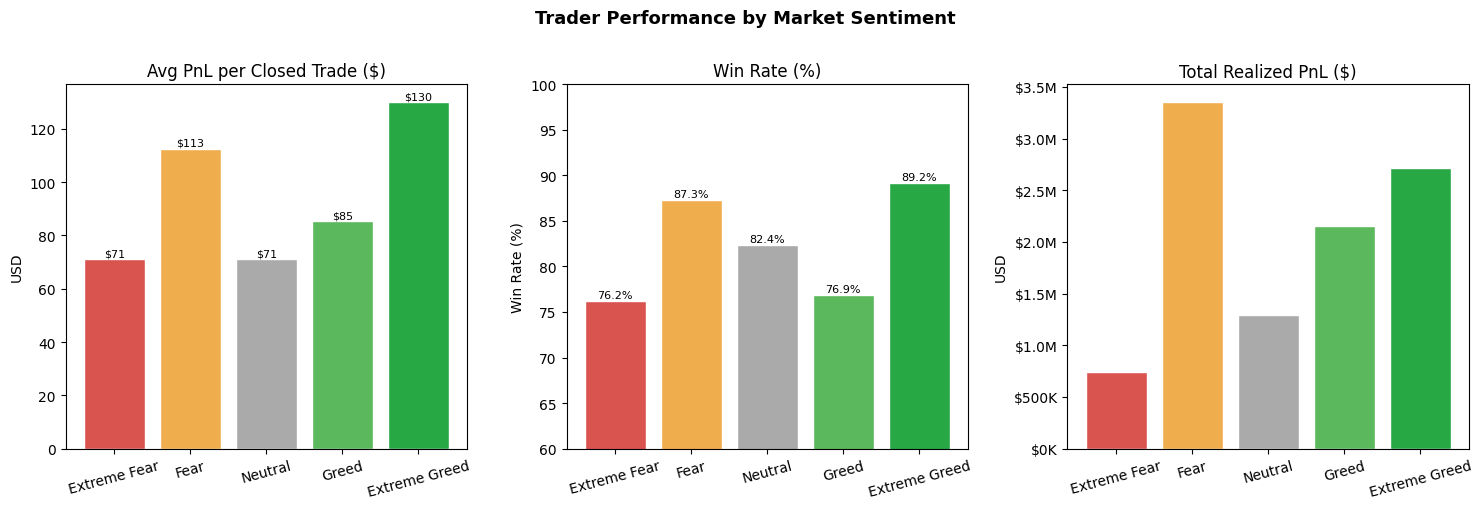

In [4]:
colors_map = {
    'Extreme Fear': '#d9534f',
    'Fear':         '#f0ad4e',
    'Neutral':      '#aaaaaa',
    'Greed':        '#5cb85c',
    'Extreme Greed':'#28a745'
}

plot_order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
plot_colors = [colors_map[s] for s in plot_order]
plot_data   = final_stats.reindex(plot_order)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Trader Performance by Market Sentiment', fontsize=13, fontweight='bold', y=1.01)

# Chart 1 — Avg PnL per Trade
axes[0].bar(plot_order, plot_data['Avg_PnL_per_Trade'], color=plot_colors, edgecolor='white')
axes[0].set_title('Avg PnL per Closed Trade ($)')
axes[0].set_ylabel('USD')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(plot_data['Avg_PnL_per_Trade']):
    axes[0].text(i, v + 1, f'${v:.0f}', ha='center', fontsize=8)

# Chart 2 — Win Rate
axes[1].bar(plot_order, plot_data['Win_Rate_%'], color=plot_colors, edgecolor='white')
axes[1].set_title('Win Rate (%)')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(60, 100)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(plot_data['Win_Rate_%']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

# Chart 3 — Total Realized PnL
axes[2].bar(plot_order, plot_data['Total_Realized_PnL'], color=plot_colors, edgecolor='white')
axes[2].set_title('Total Realized PnL ($)')
axes[2].set_ylabel('USD')
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M' if x>=1e6 else f'${x/1e3:.0f}K'))
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('chart1_sentiment_performance.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation (F&G Index vs Monthly PnL): -0.27


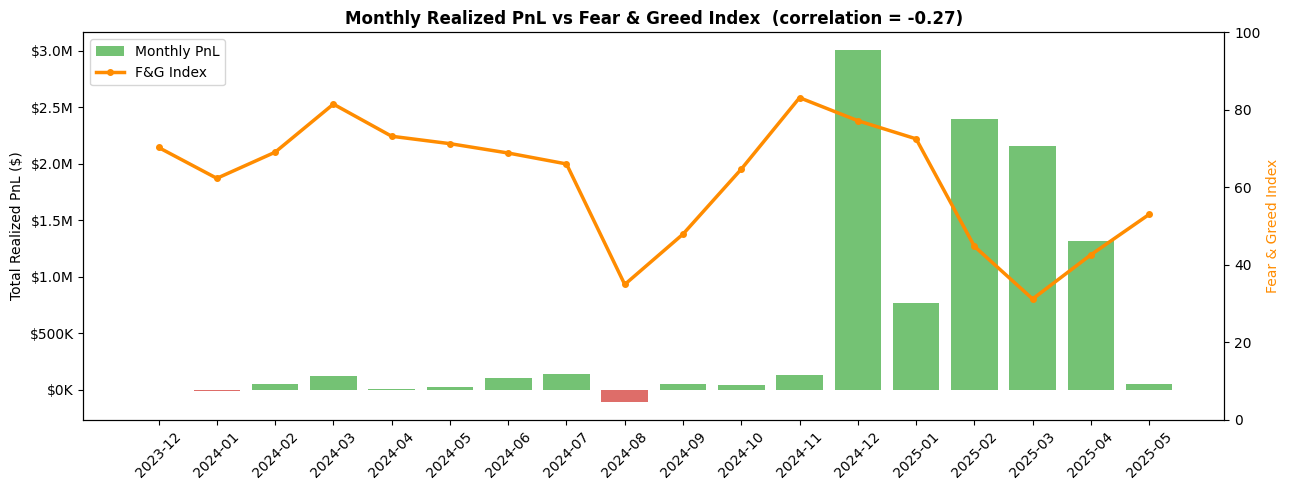

In [5]:
# Monthly PnL vs Fear & Greed trend
df_merged['Month'] = pd.to_datetime(df_merged['Date']).dt.to_period('M')
monthly_pnl = closed.groupby(pd.to_datetime(closed['Date']).dt.to_period('M'))['Closed PnL'].sum()
monthly_fg  = df_merged.groupby('Month')['value'].mean()
monthly = pd.DataFrame({'pnl': monthly_pnl, 'fg': monthly_fg}).dropna().tail(18)
monthly.index = monthly.index.astype(str)

corr = monthly['fg'].corr(monthly['pnl'])
print(f"Correlation (F&G Index vs Monthly PnL): {corr:.2f}")

fig, ax1 = plt.subplots(figsize=(13, 5))
bar_cols = ['#5cb85c' if v >= 0 else '#d9534f' for v in monthly['pnl']]
ax1.bar(monthly.index, monthly['pnl'], color=bar_cols, alpha=0.85, label='Monthly PnL')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M' if abs(x)>=1e6 else f'${x/1e3:.0f}K'))
ax1.set_ylabel('Total Realized PnL ($)')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['fg'], color='darkorange', linewidth=2.5, marker='o', markersize=4, label='F&G Index')
ax2.set_ylabel('Fear & Greed Index', color='darkorange')
ax2.set_ylim(0, 100)

ax1.set_title(f'Monthly Realized PnL vs Fear & Greed Index  (correlation = {corr:.2f})', fontweight='bold')
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2, loc='upper left')
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Directional breakdown — Close Long vs Close Short by sentiment
dir_stats = (
    closed[closed['Direction'].isin(['Close Long','Close Short'])]
    .groupby(['classification','Direction'])
    .agg(
        Trades=('Account','count'),
        Total_PnL=('Closed PnL','sum'),
        Win_Rate=('Closed PnL', lambda x: round((x>0).mean()*100, 1))
    )
    .reset_index()
)
print("--- Directional Performance by Sentiment ---")
print(dir_stats.to_string(index=False))

--- Directional Performance by Sentiment ---
classification   Direction  Trades    Total_PnL  Win_Rate
  Extreme Fear  Close Long    6241 5.067528e+05      84.6
  Extreme Fear Close Short    3117 3.846385e+05      70.6
 Extreme Greed  Close Long    7185 4.443160e+05      88.8
 Extreme Greed Close Short    6489 1.882213e+05      86.0
          Fear  Close Long   17260 1.432582e+06      89.9
          Fear Close Short    9212 1.914986e+06      86.2
         Greed  Close Long    7963 7.114905e+05      86.7
         Greed Close Short   11319 6.249234e+05      68.9
       Neutral  Close Long    9985 5.277882e+05      86.2
       Neutral Close Short    5849 5.545584e+05      77.7


## 5. Top Trader Profiles

In [7]:
top_traders = df_merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(5).index

print("--- Top 5 Traders by Total Realized PnL ---\n")
for trader in top_traders:
    data = closed[closed['Account'] == trader]
    total = data['Closed PnL'].sum()
    wr    = (data['Closed PnL'] > 0).mean() * 100
    print(f"Trader: {trader[:10]}...  |  Total PnL: ${total:>12,.2f}  |  Win Rate: {wr:.1f}%")
    breakdown = data.groupby('classification')['Closed PnL'].sum().round(2)
    print(breakdown.to_string())
    print("-" * 45)

--- Top 5 Traders by Total Realized PnL ---

Trader: 0xb1231a4a...  |  Total PnL: $2,143,382.60  |  Win Rate: 79.1%
classification
Extreme Fear        9544.91
Extreme Greed    1105304.86
Fear               93165.16
Greed             534058.24
Neutral           401309.43
---------------------------------------------
Trader: 0x083384f8...  |  Total PnL: $1,600,229.82  |  Win Rate: 79.3%
classification
Extreme Fear      124769.22
Extreme Greed     -40282.34
Fear             1113373.55
Greed             276719.27
Neutral           125650.12
---------------------------------------------
Trader: 0xbaaaf657...  |  Total PnL: $  940,163.81  |  Win Rate: 99.1%
classification
Extreme Fear    261917.98
Fear            620872.38
Greed                4.67
Neutral          57368.78
---------------------------------------------
Trader: 0x513b8629...  |  Total PnL: $  840,422.56  |  Win Rate: 89.5%
classification
Extreme Fear    -71121.82
Fear            367166.22
Greed           163047.66
Neutral    

## 6. Key Findings & Recommendations

### Finding 1 — The Fear Advantage
**Fear** conditions produced the highest total realized PnL ($6.69M) and the highest win rate (86.12%) of any sentiment regime. High volatility during fear events creates price dislocations that skilled traders exploit consistently. Algorithms should **maximize capital allocation during Fear** periods.

### Finding 2 — Extreme Greed Degrades Performance
During **Extreme Greed**, average PnL per trade collapses to just **$40.85** — the lowest of any regime — while win rates also compress (78.76%). Overcrowded long positions and late entries near local tops are the likely driver. Risk models should **scale down leverage and position sizing** in this zone.

### Finding 3 — Contrarian Selling into Greed
In standard **Greed** conditions, Sell-tagged trades and closed shorts captured outsized PnL with strong win rates. Top performers fade retail exuberance rather than chase it — a contrarian short-biased edge.

### Finding 4 — Adaptive Traders Outperform Rigid Ones
The top overall trader (`0xb123...`) extracted profits across multiple sentiment regimes. The second-highest earner (`0x0833...`) generated $1.92M in Fear but **lost $327K in Greed** — a rigid system blind to regime shifts. Strategy logic should include **sentiment-regime detection** to flip bias accordingly.

---

### Recommended Playbook

| Sentiment | Action |
|---|---|
| **Extreme Fear** | Accumulate longs aggressively; widen take-profit targets |
| **Fear** | Maximize allocation; both long and short opportunities available |
| **Neutral** | Reduce size; avoid overtrading; wait for a clear regime |
| **Greed** | Begin taking profits; bias toward contrarian short entries |
| **Extreme Greed** | Minimise exposure; tighten stops; avoid new long entries |
